### File Description

This file is responsible for presenting the graphs and thus verifying and analyzing the results of the trained models. The main function of this file is to provide a clear visualization of the models' performance in terms of forecasting and accuracy. 

This file facilitates the analysis of results, making it easier to interpret and compare the trained models.


### Imports

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import matplotlib.dates as mdates
import ast

### Analyzing raw data

In [10]:
df_raw_data = pd.read_csv("database/combined_data.csv", sep=';')

In [11]:
statistics = df_raw_data.groupby('product')['m3'].agg(
    min='min', 
    max='max', 
    mean='mean', 
    std='std'
)

print(statistics)

                            min           max           mean            std
product                                                                    
etanolhidratado        0.000000  1.077622e+06   34304.618694  101520.798647
gasolinac              5.000000  1.035389e+06   87858.227567  134453.059672
gasolinadeaviacao      0.000000  3.219495e+03     193.048990     311.585794
glp                  356.226449  3.369416e+05   37292.707901   52741.761740
oleocombustivel        0.000000  5.141312e+05   19079.105838   40634.697947
oleodiesel           478.400000  1.312177e+06  135535.235972  183412.660135
querosenedeaviacao     0.000000  3.711453e+05   15847.039397   39806.093694
queroseneiluminante    0.000000  1.481740e+04     281.774047     882.859307


In [12]:
filtered_products = ['etanolhidratado', 'gasolinac', 'glp', 'oleodiesel', 'querosenedeaviacao']
df_sp = df_raw_data[(df_raw_data['state'] == 'sp') & (df_raw_data['product'].isin(filtered_products))]

In [13]:
df_sp["product"].unique()

array(['etanolhidratado', 'gasolinac', 'glp', 'oleodiesel',
       'querosenedeaviacao'], dtype=object)

In [14]:
substitutions = {
    'etanolhidratado': 'Hydrated Ethanol',
    'gasolinac': 'Regular Gasoline',
    'gasolinadeaviacao': 'Aviation Gasoline',
    'glp': 'LPG',
    'oleocombustivel': 'Fuel Oil',
    'oleodiesel': 'Diesel Oil',
    'querosenedeaviacao': 'Aviation Kerosene',
    'queroseneiluminante': 'Illuminating Kerosene'
}

df_sp['product'] = df_sp['product'].replace(substitutions)

C:\Users\alex-\AppData\Local\Temp\ipykernel_1368\1729571111.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sp['product'] = df_sp['product'].replace(substitutions)


C:\Users\alex-\AppData\Local\Temp\ipykernel_1368\1050960541.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sp['timestamp'] = pd.to_datetime(df_sp['timestamp'], errors='coerce')


datetime64[ns]


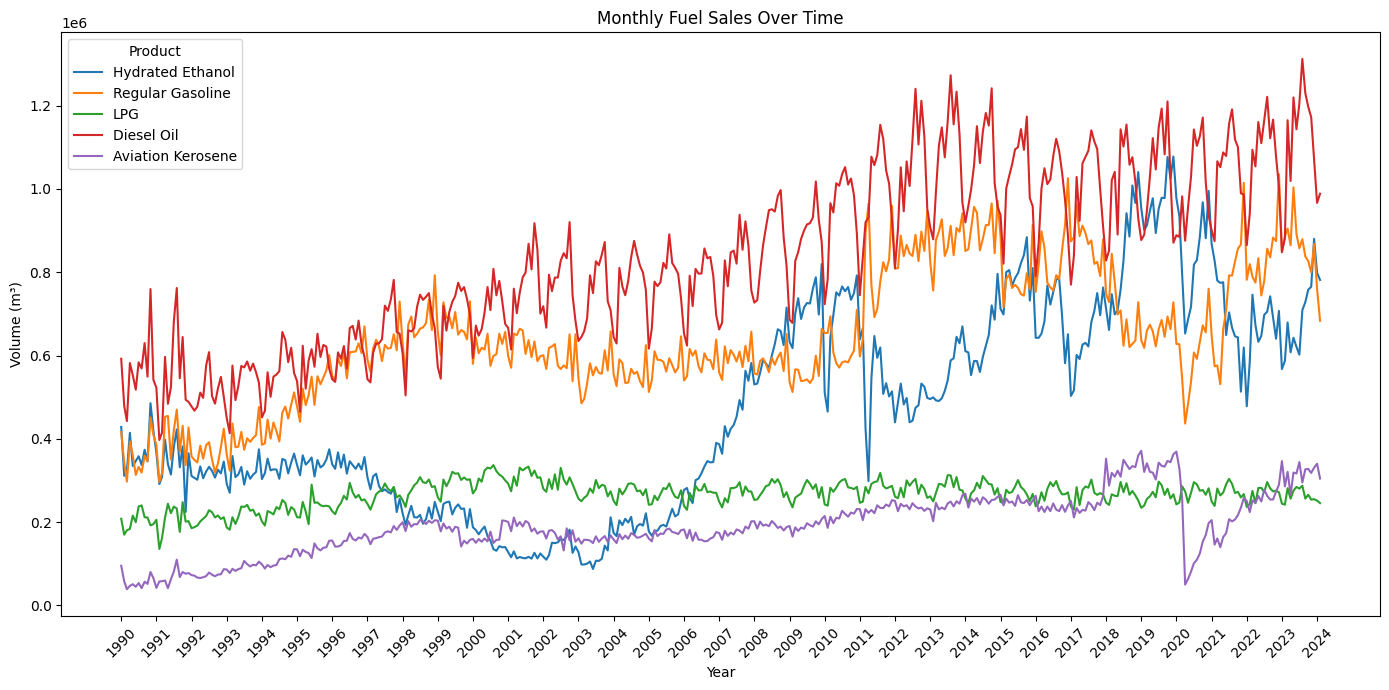

In [16]:
df_sp['timestamp'] = pd.to_datetime(df_sp['timestamp'], errors='coerce')

print(df_sp['timestamp'].dtypes)

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_sp, x='timestamp', y='m3', hue='product')

plt.title('Monthly Fuel Sales Over Time')
plt.xlabel('Year')
plt.ylabel('Volume (m³)')

unique_years = df_sp['timestamp'].dt.year.dropna().unique()
plt.xticks(ticks=[pd.Timestamp(f'{year}-01-01') for year in unique_years], labels=unique_years, rotation=45)

plt.legend(title='Product')
plt.tight_layout()
plt.show()

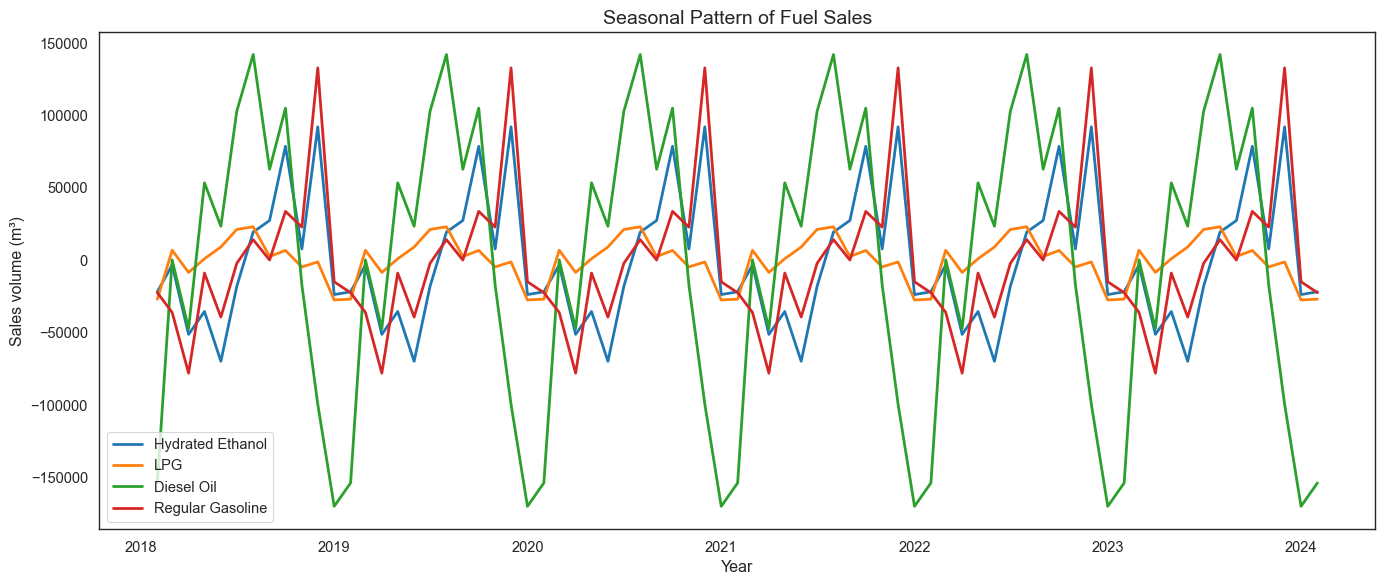

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# =========================
# Preparação dos dados
# =========================

# Garantir timestamp como datetime
df_plot['timestamp'] = pd.to_datetime(df_plot['timestamp'])

# Filtrar últimos 6 anos
df_filtered = df_plot[
    df_plot['timestamp'] >= df_plot['timestamp'].max() - pd.DateOffset(years=6)
]

def decompose_and_extract_seasonal(product_data):
    result = seasonal_decompose(
        product_data['m3'],
        model='additive',
        period=12
    )
    return result.seasonal

seasonal_components = pd.DataFrame()

for product in df_filtered['product'].unique():
    product_data = (
        df_filtered[df_filtered['product'] == product]
        .set_index('timestamp')
        .sort_index()
    )

    # Evita erro se a série for curta demais
    if len(product_data) < 24:
        continue

    seasonal = decompose_and_extract_seasonal(product_data)
    seasonal_components[product] = seasonal

seasonal_components.reset_index(inplace=True)
seasonal_components.rename(columns={'index': 'timestamp'}, inplace=True)

# =========================
# Plot (cores iguais à imagem)
# =========================

color_map = {
    'Hydrated Ethanol': 'tab:blue',
    'LPG': 'tab:orange',
    'Diesel Oil': 'tab:green',
    'Regular Gasoline': 'tab:red'
}

plt.figure(figsize=(14, 6))

for product in color_map.keys():
    if product in seasonal_components.columns:
        plt.plot(
            seasonal_components['timestamp'],
            seasonal_components[product],
            label=product,
            color=color_map[product],
            linewidth=2
        )

plt.title('Seasonal Pattern of Fuel Sales', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Sales volume (m³)')

plt.legend()
plt.tight_layout()
plt.show()


### Loading data

In [23]:
# # INFO: LAST YEAR

df_lstm = pd.read_excel("LSTM/results_model_local/lstm_results_pytorch.xlsx") 
df_beats = pd.read_excel("N-BEATS/results_model_local/nbeats_results.xlsx")

# Combinar os DataFrames
df = pd.concat([df_lstm, df_beats], ignore_index=True)

In [24]:
df = df[~df['PRODUCT'].isin(['gasolinadeaviacao', 'oleocombustivel', 'queroseneiluminante'])]

In [25]:
derivados = {
    'etanolhidratado': 'Etanol Hidratado',
    'gasolinac': 'Gasolina Comum',
    'glp': 'GLP',
    'oleodiesel': 'Óleo Diesel',
    'querosenedeaviacao': 'Querosene de Aviação'
}

df['PRODUCT'] = df['PRODUCT'].replace(derivados)

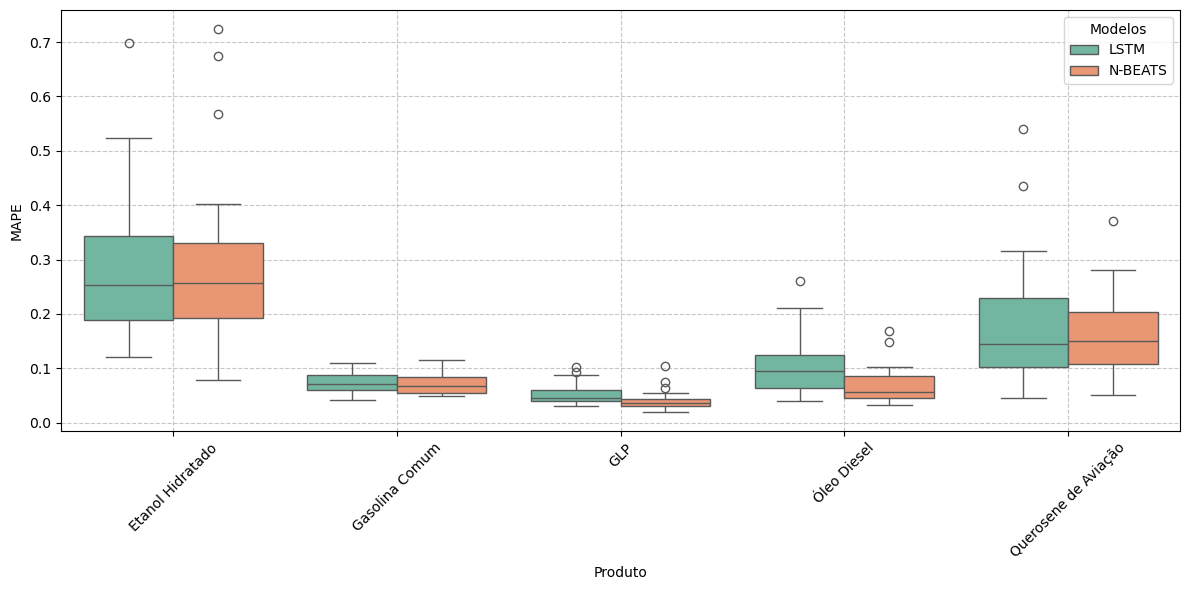

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Criar o box plot com uma paleta de cores mais agradável
plt.figure(figsize=(12, 6))
sns.boxplot(
    x="PRODUCT", 
    y="MAPE", 
    hue="MODEL", 
    data=df, 
    palette="Set2"  # Paleta bonita e harmoniosa
)
plt.xlabel("Produto")
plt.ylabel("MAPE")
plt.legend(title="Modelos")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()
